In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import r2_score

# 1. 读取数据（请确认文件路径和 sheet 名称）
df = pd.read_excel('湖库.xlsx', sheet_name='Sheet2')

# 2. 将分类文本列转换为数值
df['湖/库'] = df['湖/库'].map({'湖': 0, '库': 1})   # 湖->0, 库->1
# 确保其他列是数值类型（如果已经是数值则不变）
df['水/沉积物'] = pd.to_numeric(df['水/沉积物'], errors='coerce')
df['Flood period'] = pd.to_numeric(df['Flood period'], errors='coerce')
df['Watershed zone'] = pd.to_numeric(df['Watershed zone'], errors='coerce')
# 人口、GDP等应该是数值，但如果有逗号等需要处理，这里先假设没问题

# 3. 特征列
feature_cols = ['Watershed zone', '水/沉积物', '湖/库', 'Flood period', 
                '人口', 'Total GDP', '人均GDP', 'Altitude', 
                'Annual mean rainfall', 'Annual mean temperature']

# 4. 目标列（请使用你文件中实际的列名）
target_col = 'Log10 Abundance (items/m3 or items/kg)'   # 或者 '丰度'

# 5. 删除缺失值
df_clean = df[feature_cols + [target_col]].dropna()

# 6. 分离 X, y
X = df_clean[feature_cols].values
y = df_clean[target_col].values.reshape(-1, 1)

# 7. 划分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 8. 标准化
scaler_X = StandardScaler()
scaler_y = StandardScaler()
X_train = scaler_X.fit_transform(X_train)
X_test = scaler_X.transform(X_test)
y_train = scaler_y.fit_transform(y_train)
y_test = scaler_y.transform(y_test)

# 9. 转换为 PyTorch 张量
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32)
X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.float32)

# 10. 定义神经网络
class MicroplasticNN(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )
    def forward(self, x):
        return self.net(x)

model = MicroplasticNN(input_dim=X_train.shape[1])
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# 11. 训练
print("开始训练...")
for epoch in range(200):
    model.train()
    optimizer.zero_grad()
    pred = model(X_train_t)
    loss = criterion(pred, y_train_t)
    loss.backward()
    optimizer.step()
    if epoch % 50 == 0:
        print(f'Epoch {epoch}, Loss: {loss.item():.4f}')

# 12. 测试
model.eval()
with torch.no_grad():
    pred_test = model(X_test_t)
    pred_test = scaler_y.inverse_transform(pred_test.numpy())
    y_test_orig = scaler_y.inverse_transform(y_test_t.numpy())
    r2 = r2_score(y_test_orig, pred_test)
    print(f'\n测试集 R²: {r2:.3f}')

开始训练...
Epoch 0, Loss: 1.0824
Epoch 50, Loss: 0.3416
Epoch 100, Loss: 0.2596
Epoch 150, Loss: 0.2102

测试集 R²: 0.781


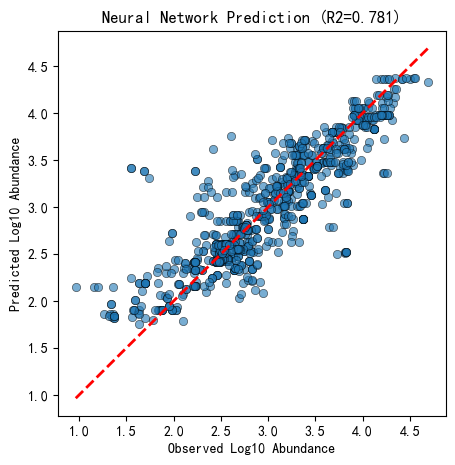

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(5,5))
plt.scatter(y_test_orig, pred_test, alpha=0.6, edgecolors='k', linewidth=0.5)
plt.plot([y_test_orig.min(), y_test_orig.max()], 
         [y_test_orig.min(), y_test_orig.max()], 'r--', lw=2)
plt.xlabel('Observed Log10 Abundance')
plt.ylabel('Predicted Log10 Abundance')
plt.title(f'Neural Network Prediction (R2={r2:.3f})')
plt.savefig('prediction_scatter.png', dpi=150)
plt.show()